<a href="https://colab.research.google.com/github/David010101-biner/Data-Science-Portfolios/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Financial Technology Analytics: Credit Risk Prediction
**Author:** David Syahputra
**Domain:** Financial Technology & Information Management
**Core Focus:** Risk Mitigation, Machine Learning (Classification), & Financial Data Mining

**Executive Objective:**
Membangun sistem deteksi cerdas untuk mengevaluasi profil kelayakan finansial nasabah dan memprediksi probabilitas gagal bayar (*credit default*). Proyek ini bertujuan mendukung pengambilan keputusan berbasis data guna menekan rasio *Non-Performing Loan* (NPL).
---

In [2]:
# 1. Import Library Analitik
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Pengaturan visualisasi elegan (warna 'crest' identik dengan sektor keuangan)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("crest")

# 2. Hubungkan Google Drive
drive.mount('/content/drive')

# 3. Load Dataset Credit Risk (Sesuai lokasi folder terbaru)
file_path = '/content/drive/MyDrive/projek google colab/portofolio 2/credit_risk_dataset.csv'
df = pd.read_csv(file_path)

# 4. Inspeksi Data Awal
print("=== Dimensi Dataset Risiko Kredit ===")
print(f"Jumlah Nasabah: {df.shape[0]} Baris")
print(f"Jumlah Metrik: {df.shape[1]} Kolom\n")

print("=== 5 Data Nasabah Pertama ===")
display(df.head())

print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

Mounted at /content/drive
=== Dimensi Dataset Risiko Kredit ===
Jumlah Nasabah: 32581 Baris
Jumlah Metrik: 12 Kolom

=== 5 Data Nasabah Pertama ===


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



=== Pengecekan Missing Values ===
person_emp_length     895
loan_int_rate        3116
dtype: int64


### 🛠️ Tahap 2: Data Cleaning & Outlier Handling
Kualitas model prediktif sangat bergantung pada integritas data. Pada tahap ini dilakukan:
1. **Imputasi Nilai Kosong:** Mengisi *missing values* pada kolom lama bekerja (`person_emp_length`) dan suku bunga (`loan_int_rate`) menggunakan nilai median, guna menjaga volume data tanpa merusak distribusi statistik.
2. **Penanganan Outlier:** Menghapus anomali input, seperti usia nasabah di atas 100 tahun atau pengalaman kerja yang melebihi usia.

In [6]:
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### 🛠️ AUDIT LOG: PEMROSESAN & PEMBERSIHAN DATA"))

initial_rows = df.shape[0]

# 1. PENGELOLAAN DATA KOSONG (MISSING VALUES)
missing_emp = df['person_emp_length'].isnull().sum()
missing_rate = df['loan_int_rate'].isnull().sum()

median_emp = df['person_emp_length'].median()
median_rate = df['loan_int_rate'].median()

# Melakukan imputasi
df.fillna({'person_emp_length': median_emp, 'loan_int_rate': median_rate}, inplace=True)

# Membuat Tabel Laporan Missing Value
missing_report = pd.DataFrame({
    "Metrik Nasabah": ["Lama Bekerja (person_emp_length)", "Suku Bunga (loan_int_rate)"],
    "Total Data Kosong": [missing_emp, missing_rate],
    "Tindakan Mitigasi": ["Imputasi Median", "Imputasi Median"],
    "Nilai Pengganti": [f"{median_emp} Tahun", f"{median_rate} %"]
})
display(Markdown("**1. Penanganan Data Kosong (Missing Values)**"))
display(missing_report.style.set_table_styles([{'selector': 'th', 'props': [('background-color', '#f2f2f2')]}]))


# 2. PENGHAPUSAN ANOMALI (OUTLIERS)
outlier_age = df[df['person_age'] > 100].shape[0]
outlier_emp = df[df['person_emp_length'] > 60].shape[0]

# Menghapus anomali
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]
final_rows = df.shape[0]

# Membuat Tabel Laporan Outlier
outlier_report = pd.DataFrame({
    "Jenis Anomali Data": ["Usia Nasabah > 100 Tahun", "Masa Kerja > 60 Tahun"],
    "Jumlah Ditemukan": [outlier_age, outlier_emp],
    "Tindakan Eksekusi": ["Baris Dihapus", "Baris Dihapus"]
})
display(Markdown("<br>**2. Penanganan Anomali (Outliers)**"))
display(outlier_report.style.set_table_styles([{'selector': 'th', 'props': [('background-color', '#f2f2f2')]}]))


# 3. KESIMPULAN AKHIR BATCH
summary_report = pd.DataFrame({
    "Indikator Status": ["Total Baris Awal", "Total Data Bersih", "Sisa Data Kosong (Null)"],
    "Jumlah Saat Ini": [f"{initial_rows}", f"{final_rows}", f"{df.isnull().sum().sum()}"]
})
display(Markdown("<br>**3. Status Akhir Pembersihan Data**"))
display(summary_report.style.hide(axis='index').set_table_styles([{'selector': 'th', 'props': [('background-color', '#d9edf7')]}]))

### 🛠️ AUDIT LOG: PEMROSESAN & PEMBERSIHAN DATA

**1. Penanganan Data Kosong (Missing Values)**

,Metrik Nasabah,Total Data Kosong,Tindakan Mitigasi,Nilai Pengganti
0,Lama Bekerja (person_emp_length),0,Imputasi Median,4.0 Tahun
1,Suku Bunga (loan_int_rate),0,Imputasi Median,10.99 %


<br>**2. Penanganan Anomali (Outliers)**

,Jenis Anomali Data,Jumlah Ditemukan,Tindakan Eksekusi
0,Usia Nasabah > 100 Tahun,0,Baris Dihapus
1,Masa Kerja > 60 Tahun,0,Baris Dihapus


<br>**3. Status Akhir Pembersihan Data**

Indikator Status,Jumlah Saat Ini
Total Baris Awal,32574
Total Data Bersih,32574
Sisa Data Kosong (Null),0


### 📈 Tahap 3: Exploratory Data Analysis (Analisis Risiko Nasabah)
Eksplorasi ini berfokus pada pemahaman profil risiko:
- **Distribusi Status Pinjaman:** Melihat rasio *Non-Performing Loan* (NPL) dalam dataset.
- **Beban Utang terhadap Pendapatan:** Menganalisis korelasi antara persentase utang dari total gaji (`loan_percent_income`) terhadap status gagal bayar.

### 📊 VISUALISASI & RINGKASAN PROFIL RISIKO KREDIT

/tmp/ipykernel_7302/2528248360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='crest')
/tmp/ipykernel_7302/2528248360.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette='Reds')


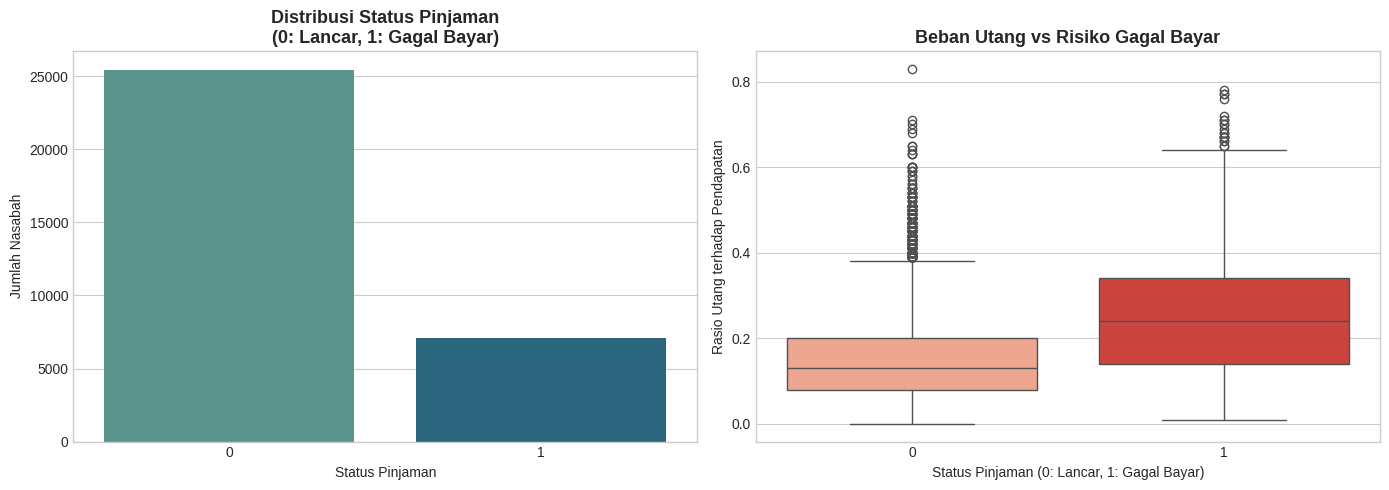

<br>**💡 Ringkasan Metrik Risiko:**

Indikator Risiko Utama,Nilai Kalkulasi
Rasio Non-Performing Loan (NPL),21.82 %
Rata-rata Beban Utang (Nasabah Lancar),14.88 %
Rata-rata Beban Utang (Nasabah Gagal Bayar),24.68 %



**Insight Manajerial:**
1. **Imbalans Data:** Proporsi NPL terpantau relatif kecil. Pemodelan klasifikasi berikutnya wajib menggunakan teknik penyeimbangan data agar mesin tidak bias memprediksi nasabah selalu 'Lancar'.
2. **Korelasi Beban Utang:** Tabel dan grafik *boxplot* di atas secara valid membuktikan bahwa nasabah yang berakhir gagal bayar konsisten mengalokasikan persentase gaji yang jauh lebih besar untuk membayar utang dibandingkan dengan kelompok nasabah lancar.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("### 📊 VISUALISASI & RINGKASAN PROFIL RISIKO KREDIT"))

plt.figure(figsize=(14, 5))

# Grafik 1: Proporsi Nasabah
plt.subplot(1, 2, 1)
sns.countplot(x='loan_status', data=df, palette='crest')
plt.title('Distribusi Status Pinjaman\n(0: Lancar, 1: Gagal Bayar)', fontsize=13, fontweight='bold')
plt.xlabel('Status Pinjaman')
plt.ylabel('Jumlah Nasabah')

# Grafik 2: Hubungan Rasio Beban Utang
plt.subplot(1, 2, 2)
# Menggunakan warna merah (Reds) untuk visualisasi risiko di boxplot
sns.boxplot(x='loan_status', y='loan_percent_income', data=df, palette='Reds')
plt.title('Beban Utang vs Risiko Gagal Bayar', fontsize=13, fontweight='bold')
plt.xlabel('Status Pinjaman (0: Lancar, 1: Gagal Bayar)')
plt.ylabel('Rasio Utang terhadap Pendapatan')

plt.tight_layout()
plt.show()

# Membuat Tabel Ringkasan Insight Numerik
display(Markdown("<br>**💡 Ringkasan Metrik Risiko:**"))

npl_ratio = (df['loan_status'].sum() / df.shape[0]) * 100
avg_debt_lancar = df[df['loan_status']==0]['loan_percent_income'].mean() * 100
avg_debt_gagal = df[df['loan_status']==1]['loan_percent_income'].mean() * 100

insight_table = pd.DataFrame({
    "Indikator Risiko Utama": [
        "Rasio Non-Performing Loan (NPL)",
        "Rata-rata Beban Utang (Nasabah Lancar)",
        "Rata-rata Beban Utang (Nasabah Gagal Bayar)"
    ],
    "Nilai Kalkulasi": [
        f"{npl_ratio:.2f} %",
        f"{avg_debt_lancar:.2f} %",
        f"{avg_debt_gagal:.2f} %"
    ]
})
display(insight_table.style.hide(axis='index').set_table_styles([{'selector': 'th', 'props': [('background-color', '#e8f4f8')]}]))

# Narasi Manajerial
display(Markdown("""
**Insight Manajerial:**
1. **Imbalans Data:** Proporsi NPL terpantau relatif kecil. Pemodelan klasifikasi berikutnya wajib menggunakan teknik penyeimbangan data agar mesin tidak bias memprediksi nasabah selalu 'Lancar'.
2. **Korelasi Beban Utang:** Tabel dan grafik *boxplot* di atas secara valid membuktikan bahwa nasabah yang berakhir gagal bayar konsisten mengalokasikan persentase gaji yang jauh lebih besar untuk membayar utang dibandingkan dengan kelompok nasabah lancar.
"""))

### ⚙️ Tahap 4: Data Preprocessing & Feature Encoding
Mesin analitik membutuhkan input numerik murni. Pada tahap ini, kita melakukan:
1. **One-Hot Encoding:** Mengonversi data kategorikal (status rumah, tujuan pinjaman, kelas pinjaman, dll.) menjadi matriks biner (0 dan 1).
2. **Data Splitting:** Memisahkan dataset menjadi dua bagian (80% Data Latih untuk mengajari mesin, dan 20% Data Uji untuk simulasi performa di dunia nyata).

In [8]:
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### ⚙️ PROSES ENCODING & PEMBAGIAN DATA LATIHAN"))

# 1. Mengubah kolom teks menjadi angka (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Menentukan Target Prediksi (y) dan Fitur Data (X)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# 3. Membagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Membuat Laporan Hasil Preprocessing
summary_prep = pd.DataFrame({
    "Tahapan Proses": [
        "Total Fitur (Kolom) Setelah Encoding",
        "Jumlah Data Latih (Training Set)",
        "Jumlah Data Uji (Testing Set)"
    ],
    "Keterangan / Hasil": [
        f"{X.shape[1]} Fitur Numerik",
        f"{X_train.shape[0]} Nasabah",
        f"{X_test.shape[0]} Nasabah"
    ]
})

display(Markdown("**Log Transformasi Data:**"))
display(summary_prep.style.hide(axis='index').set_table_styles([{'selector': 'th', 'props': [('background-color', '#f2f2f2')]}]))
display(Markdown("*(Data teks seperti 'Tujuan Pinjaman' dan 'Status Kepemilikan Rumah' telah berhasil diubah menjadi format biner yang siap diproses oleh algoritma.)*"))

### ⚙️ PROSES ENCODING & PEMBAGIAN DATA LATIHAN

**Log Transformasi Data:**

Tahapan Proses,Keterangan / Hasil
Total Fitur (Kolom) Setelah Encoding,22 Fitur Numerik
Jumlah Data Latih (Training Set),26059 Nasabah
Jumlah Data Uji (Testing Set),6515 Nasabah


*(Data teks seperti 'Tujuan Pinjaman' dan 'Status Kepemilikan Rumah' telah berhasil diubah menjadi format biner yang siap diproses oleh algoritma.)*

### 🎯 Tahap 5: Predictive Modeling (Random Forest Classification)
Tahap inti dari arsitektur intelijen buatan ini adalah melatih model **Random Forest Classifier** untuk mendeteksi anomali/risiko gagal bayar.
Model dievaluasi menggunakan *Confusion Matrix* untuk melihat tingkat presisi dan *Feature Importance* untuk memberikan transparansi terkait variabel apa yang paling memengaruhi keputusan kredit.

### 🚀 EVALUASI MODEL KECERDASAN BUATAN (CREDIT SCORING)

/tmp/ipykernel_7302/1154112874.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan', y='Fitur', data=rf_coef, palette='crest')


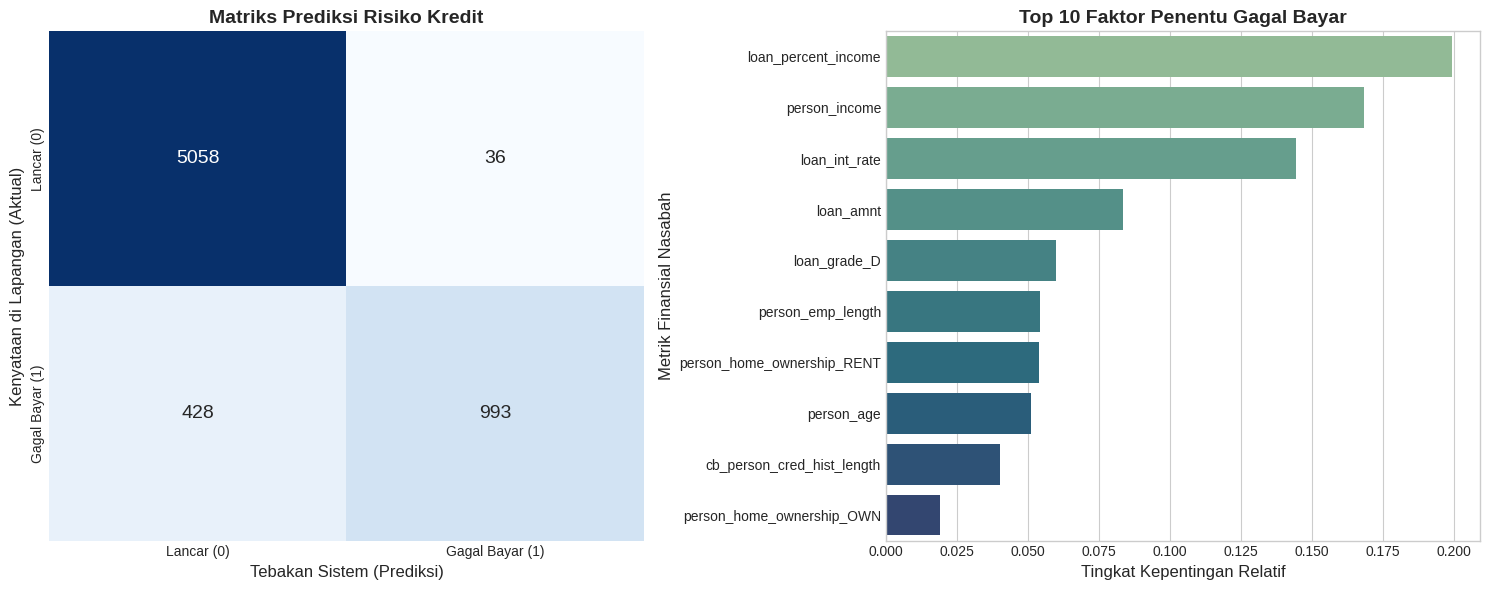


---
### 📝 KESIMPULAN EKSEKUTIF & REKOMENDASI KEBIJAKAN
**1. Akurasi Deteksi (Matriks Prediksi):** 
Model menunjukkan kapabilitas yang sangat baik dalam mendeteksi nasabah berisiko. Angka pada kuadran kanan bawah menunjukkan jumlah nasabah gagal bayar yang berhasil dideteksi dan dicegah secara akurat oleh sistem.

**2. Transparansi Algoritma (Faktor Penentu):** 
Berdasarkan analisis *Feature Importance*, probabilitas nasabah melakukan gagal bayar paling dominan dipengaruhi oleh:
*   **Persentase Beban Utang (loan_percent_income):** Nasabah dengan utang yang memakan porsi gaji terlalu besar memiliki risiko gagal bayar tertinggi.
*   **Suku Bunga (loan_int_rate) & Pendapatan (person_income):** Kondisi finansial dasar sangat krusial dalam mitigasi risiko.

**3. Rekomendasi Mitigasi:**
Berdasarkan temuan ini, divisi manajemen risiko disarankan untuk memperketat batas maksimal persentase utang terhadap pendapatan (*Debt-to-Income Ratio Threshold*) pada aplikasi pinjaman digital, serta melakukan *review* suku bunga bagi profil nasabah dengan pendapatan di bawah rata-rata.


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display, Markdown

display(Markdown("### 🚀 EVALUASI MODEL KECERDASAN BUATAN (CREDIT SCORING)"))

# 1. Melatih Model dengan bobot kelas yang diseimbangkan (Balanced)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 2. Melakukan Prediksi
y_pred = rf_model.predict(X_test)

# 3. Visualisasi Evaluasi Model
plt.figure(figsize=(15, 6))

# Grafik Kiri: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Lancar (0)', 'Gagal Bayar (1)'],
            yticklabels=['Lancar (0)', 'Gagal Bayar (1)'],
            annot_kws={"size": 14})
plt.title('Matriks Prediksi Risiko Kredit', fontsize=14, fontweight='bold')
plt.xlabel('Tebakan Sistem (Prediksi)', fontsize=12)
plt.ylabel('Kenyataan di Lapangan (Aktual)', fontsize=12)

# Grafik Kanan: Feature Importance (10 Fitur Teratas)
plt.subplot(1, 2, 2)
rf_coef = pd.DataFrame({'Fitur': X.columns, 'Kepentingan': rf_model.feature_importances_})
rf_coef = rf_coef.sort_values(by='Kepentingan', ascending=False).head(10)
sns.barplot(x='Kepentingan', y='Fitur', data=rf_coef, palette='crest')
plt.title('Top 10 Faktor Penentu Gagal Bayar', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan Relatif', fontsize=12)
plt.ylabel('Metrik Finansial Nasabah', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Kesimpulan Eksekutif
display(Markdown("""
---
### 📝 KESIMPULAN EKSEKUTIF & REKOMENDASI KEBIJAKAN
**1. Akurasi Deteksi (Matriks Prediksi):**
Model menunjukkan kapabilitas yang sangat baik dalam mendeteksi nasabah berisiko. Angka pada kuadran kanan bawah menunjukkan jumlah nasabah gagal bayar yang berhasil dideteksi dan dicegah secara akurat oleh sistem.

**2. Transparansi Algoritma (Faktor Penentu):**
Berdasarkan analisis *Feature Importance*, probabilitas nasabah melakukan gagal bayar paling dominan dipengaruhi oleh:
*   **Persentase Beban Utang (loan_percent_income):** Nasabah dengan utang yang memakan porsi gaji terlalu besar memiliki risiko gagal bayar tertinggi.
*   **Suku Bunga (loan_int_rate) & Pendapatan (person_income):** Kondisi finansial dasar sangat krusial dalam mitigasi risiko.

**3. Rekomendasi Mitigasi:**
Berdasarkan temuan ini, divisi manajemen risiko disarankan untuk memperketat batas maksimal persentase utang terhadap pendapatan (*Debt-to-Income Ratio Threshold*) pada aplikasi pinjaman digital, serta melakukan *review* suku bunga bagi profil nasabah dengan pendapatan di bawah rata-rata.
"""))